In [1]:
import pandas as pd
import os

In [2]:
df = pd.read_csv("college outcomes project/college_outcomes_2026.csv")

In [3]:
#inspecting the datatypes and column names
df.head()

,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,...,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
0,opeid031505-51.07-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,1.0,0.053,0.368,1.0,31.95,OpenAI ChatGPT,reported,reported,reported,reported
1,opeid031505-51.35-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.000,0.0,5.50,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
2,opeid031505-52.04-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.167,0.0,18.11,NaN,reported,privacy_suppressed,privacy_suppressed,privacy_suppressed
3,493868-12.04-1,493868.0,42833,A Better U Beauty Barber Academy,"Private, for-profit",1,Albuquerque,NM,Southwest,35.110630,...,0.0,0.000,0.000,0.0,5.12,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
4,177834-13.06-5,177834.0,2477,A T Still University of Health Sciences,"Private, nonprofit",1,Kirksville,MO,Plains,40.193648,...,2.0,0.333,0.333,2.0,35.00,Angoss KnowledgeSEEKER; SAS Enterprise Miner; ...,privacy_suppressed,not_available,not_available,not_available


In [4]:
# deleting the columns that do not help answer the questions defined in the problem statement
cols = df.columns
print(cols)
columns_to_be_used = ["institution_is_hbcu", "institution_admission_rate", "institution_tuition_in_state_usd",
                      "cip_family_title", "credential_name", "median_earnings_4yr_usd", "not_working_count_5yr",
                      "ai_software_occupation_share", "largest_linked_occupation", "earnings_trajectory_category",
                      "expert_system_occupation_share", "credential_name","institution_region"]
result = set(columns_to_be_used).issubset(cols)
print(result)

columns_to_be_removed = set(cols) - set(columns_to_be_used)
columns_to_be_removed = list(columns_to_be_removed)
print(columns_to_be_removed)

df = df.drop(columns = columns_to_be_removed)
df.columns

Index(['program_id', 'unitid', 'opeid6', 'institution_name',
       'institution_control', 'is_main_campus', 'institution_city',
       'institution_state', 'institution_region', 'institution_latitude',
       'institution_longitude', 'institution_is_hbcu',
       'institution_admission_rate', 'institution_avg_sat',
       'institution_undergrad_enrollment', 'institution_tuition_in_state_usd',
       'institution_tuition_out_state_usd', 'cip_code_4digit', 'cip_title',
       'cip_family_code', 'cip_family_title', 'credential_level',
       'credential_name', 'distance_education', 'awards_year1', 'awards_year2',
       'outcomes_shared_across_campuses', 'median_earnings_4yr_usd',
       'earnings_cohort_size_4yr', 'national_median_earnings_4yr_usd',
       'national_p25_earnings_4yr_usd', 'national_p75_earnings_4yr_usd',
       'earnings_vs_national_pct', 'median_earnings_1yr_usd',
       'earnings_cohort_size_1yr', 'median_earnings_5yr_usd',
       'earnings_cohort_size_5yr', 'not_work

Index(['institution_region', 'institution_is_hbcu',
       'institution_admission_rate', 'institution_tuition_in_state_usd',
       'cip_family_title', 'credential_name', 'median_earnings_4yr_usd',
       'not_working_count_5yr', 'earnings_trajectory_category',
       'largest_linked_occupation', 'ai_software_occupation_share',
       'expert_system_occupation_share'],
      dtype='object')

In [5]:
# understanding the remaining data
df.head()
# df.info()
# df.describe()

,institution_region,institution_is_hbcu,institution_admission_rate,institution_tuition_in_state_usd,cip_family_title,credential_name,median_earnings_4yr_usd,not_working_count_5yr,earnings_trajectory_category,largest_linked_occupation,ai_software_occupation_share,expert_system_occupation_share
0,NaN,NaN,NaN,NaN,Health Professions and Related Programs,Undergraduate Certificate or Diploma,33231.0,10.0,steady,First-line supervisors of office and administr...,0.053,0.368
1,NaN,NaN,NaN,NaN,Health Professions and Related Programs,Undergraduate Certificate or Diploma,NaN,NaN,NaN,"Health specialties teachers, postsecondary",0.000,0.000
2,NaN,NaN,NaN,NaN,"Business, Management, Marketing, and Related S...",Undergraduate Certificate or Diploma,25379.0,2.0,NaN,Customer service representatives,0.000,0.167
3,Southwest,0.0,NaN,NaN,"Culinary, Entertainment, and Personal Services",Undergraduate Certificate or Diploma,NaN,NaN,NaN,"Hairdressers, hairstylists, and cosmetologists",0.000,0.000
4,Plains,0.0,NaN,NaN,Education,Master's Degree,NaN,NaN,NaN,Management analysts,0.333,0.333


In [6]:
#removing rows not pertaining to undergraduates
degree_types = df["credential_name"].unique()
print(degree_types)

df = df.drop(df[df["credential_name"] != "Bachelor's Degree"].index)
print(df["credential_name"].unique())

df.head()
df.sample(10)

['Undergraduate Certificate or Diploma' "Master's Degree"
 'Doctoral Degree' 'Graduate/Professional Certificate'
 'Post-baccalaureate Certificate' 'First Professional Degree'
 "Associate's Degree" "Bachelor's Degree"
 'Non-Credential Program (Preparatory Coursework/Teacher Certification)']
["Bachelor's Degree"]


,institution_region,institution_is_hbcu,institution_admission_rate,institution_tuition_in_state_usd,cip_family_title,credential_name,median_earnings_4yr_usd,not_working_count_5yr,earnings_trajectory_category,largest_linked_occupation,ai_software_occupation_share,expert_system_occupation_share
97976,Mid East,0.0,0.8102,45770.0,"Liberal Arts and Sciences, General Studies and...",Bachelor's Degree,NaN,1.0,NaN,"Postsecondary teachers, all other",NaN,NaN
140737,Mid East,0.0,0.5815,17929.0,Health Professions and Related Programs,Bachelor's Degree,61901.0,0.0,NaN,NaN,NaN,NaN
151591,Mid East,0.0,0.2105,67290.0,"Foreign Languages, Literatures, and Linguistics",Bachelor's Degree,56595.0,1.0,NaN,"Secondary school teachers, except special and ...",0.000,0.000
133866,Great Lakes,0.0,0.4987,9992.0,Engineering,Bachelor's Degree,107031.0,4.0,steady,Industrial engineers,0.250,0.500
151098,Mid East,0.0,0.9589,68780.0,Physical Sciences,Bachelor's Degree,NaN,NaN,NaN,"Secondary school teachers, except special and ...",0.143,0.143
66925,Mid East,0.0,0.7232,21700.0,Visual and Performing Arts,Bachelor's Degree,NaN,NaN,NaN,"Managers, all other",0.000,0.000
18890,Mid East,0.0,0.2893,67812.0,"Business, Management, Marketing, and Related S...",Bachelor's Degree,NaN,NaN,NaN,General and operations managers,0.333,0.250
126409,Southeast,0.0,0.8199,40650.0,Family and Consumer Sciences/Human Sciences,Bachelor's Degree,NaN,NaN,NaN,Childcare workers,0.000,0.111
108135,Great Lakes,0.0,0.5912,38150.0,Education,Bachelor's Degree,NaN,0.0,NaN,"Elementary school teachers, except special edu...",0.034,0.034
104410,Plains,0.0,0.9053,9502.0,Physical Sciences,Bachelor's Degree,NaN,1.0,NaN,"Secondary school teachers, except special and ...",0.000,0.250


In [7]:
df.describe()
df.dtypes

institution_region                   object
institution_is_hbcu                 float64
institution_admission_rate          float64
institution_tuition_in_state_usd    float64
cip_family_title                     object
credential_name                      object
median_earnings_4yr_usd             float64
not_working_count_5yr               float64
earnings_trajectory_category         object
largest_linked_occupation            object
ai_software_occupation_share        float64
expert_system_occupation_share      float64
dtype: object

In [8]:
#Typecasting all tuition values into floats

df["institution_tuition_in_state_usd"] = df["institution_tuition_in_state_usd"].astype(float)

df.dtypes

institution_region                   object
institution_is_hbcu                 float64
institution_admission_rate          float64
institution_tuition_in_state_usd    float64
cip_family_title                     object
credential_name                      object
median_earnings_4yr_usd             float64
not_working_count_5yr               float64
earnings_trajectory_category         object
largest_linked_occupation            object
ai_software_occupation_share        float64
expert_system_occupation_share      float64
dtype: object

In [9]:
# Investigating why there is at least one record from an institution with a 0% admissions average

zero_admission = df[df["institution_admission_rate"] == 0]
zero_admission

len(zero_admission)

#removing the 8 records with zero admission rate
df = df[df['institution_admission_rate'] != 0]
df.isnull().sum()
df.describe()

,institution_is_hbcu,institution_admission_rate,institution_tuition_in_state_usd,median_earnings_4yr_usd,not_working_count_5yr,ai_software_occupation_share,expert_system_occupation_share
count,68626.000000,62204.000000,67828.000000,27617.000000,53546.000000,68377.000000,68377.000000
mean,0.035176,0.714579,27118.743955,64251.848897,3.345479,0.094087,0.116072
std,0.184226,0.226688,19088.231968,20786.330887,19.176330,0.168799,0.194855
min,0.000000,0.025700,0.000000,16087.000000,0.000000,0.000000,0.000000
25%,0.000000,0.617100,10320.000000,49818.000000,0.000000,0.000000,0.000000
50%,0.000000,0.772100,19440.000000,59399.000000,1.000000,0.000000,0.000000
75%,0.000000,0.881800,40664.000000,75345.000000,3.000000,0.111000,0.143000
max,1.000000,1.000000,72097.000000,297029.000000,1043.000000,1.000000,1.000000


In [10]:
regions_list = df["institution_region"].unique()
print(regions_list)

[nan 'Southeast' 'Great Lakes' 'Far West' 'Rocky Mountains' 'Southwest'
 'Plains' 'Mid East' 'New England' 'Outlying Areas' 'U.S. Service Schools']


In [11]:
# removing the records whose institutions have no regions
df = df.dropna(subset = ["institution_region"])
regions_list = df["institution_region"].unique()
print(regions_list)

df.isnull().sum()

['Southeast' 'Great Lakes' 'Far West' 'Rocky Mountains' 'Southwest'
 'Plains' 'Mid East' 'New England' 'Outlying Areas' 'U.S. Service Schools']


institution_region                      0
institution_is_hbcu                     0
institution_admission_rate           6422
institution_tuition_in_state_usd      798
cip_family_title                        0
credential_name                         0
median_earnings_4yr_usd             41578
not_working_count_5yr               16890
earnings_trajectory_category        48427
largest_linked_occupation            1870
ai_software_occupation_share         3068
expert_system_occupation_share       3068
dtype: int64

In [12]:
# removing the records whose largest linked occupation and ai software occupation share are not listed

df = df.dropna(subset = ["largest_linked_occupation"])
df = df.dropna(subset = ["ai_software_occupation_share"])
df.isnull().sum()

institution_region                      0
institution_is_hbcu                     0
institution_admission_rate           6110
institution_tuition_in_state_usd      757
cip_family_title                        0
credential_name                         0
median_earnings_4yr_usd             39498
not_working_count_5yr               15913
earnings_trajectory_category        46025
largest_linked_occupation               0
ai_software_occupation_share            0
expert_system_occupation_share          0
dtype: int64

In [13]:
df.isnull().sum()
#df.describe()

institution_region                      0
institution_is_hbcu                     0
institution_admission_rate           6110
institution_tuition_in_state_usd      757
cip_family_title                        0
credential_name                         0
median_earnings_4yr_usd             39498
not_working_count_5yr               15913
earnings_trajectory_category        46025
largest_linked_occupation               0
ai_software_occupation_share            0
expert_system_occupation_share          0
dtype: int64

In [14]:
#Replacing the missing insitution admission rates with the median admission rate

df["admission_imputed"] = df["institution_admission_rate"].isnull()
df["admission_imputed"] = df["admission_imputed"].astype(int)

df["institution_admission_rate"] = df["institution_admission_rate"].fillna(df["institution_admission_rate"].median())
df.isnull().sum()

institution_region                      0
institution_is_hbcu                     0
institution_admission_rate              0
institution_tuition_in_state_usd      757
cip_family_title                        0
credential_name                         0
median_earnings_4yr_usd             39498
not_working_count_5yr               15913
earnings_trajectory_category        46025
largest_linked_occupation               0
ai_software_occupation_share            0
expert_system_occupation_share          0
admission_imputed                       0
dtype: int64

In [15]:
#Replacing the missing tuition with the regional median

df["tuition_imputed"] = df["institution_tuition_in_state_usd"].isnull()
df["tuition_imputed"] = df["tuition_imputed"].astype(int)

df["institution_tuition_in_state_usd"] = df.groupby("institution_region")["institution_tuition_in_state_usd"].transform(lambda x: x.fillna(x.median()))
df.isnull().sum()
# df.info()
# df.describe()

institution_region                      0
institution_is_hbcu                     0
institution_admission_rate              0
institution_tuition_in_state_usd        0
cip_family_title                        0
credential_name                         0
median_earnings_4yr_usd             39498
not_working_count_5yr               15913
earnings_trajectory_category        46025
largest_linked_occupation               0
ai_software_occupation_share            0
expert_system_occupation_share          0
admission_imputed                       0
tuition_imputed                         0
dtype: int64

In [16]:
# Creating a column with the national median 4-year earnings of an American who has completed their bachelors degree

df["national_bachelors_median"] = 57000
df["earnings_difference"] = df["median_earnings_4yr_usd"] - df["national_bachelors_median"]

In [17]:
# Creating a seperate earnings dataframe as there are many missing earnings-related values

earnings_df = df.dropna(subset = ["earnings_trajectory_category"])
earnings_df.isnull().sum()
earnings_df = earnings_df.dropna(subset = ["median_earnings_4yr_usd"])
earnings_df.isnull().sum()

earnings_df.sample(7)

,institution_region,institution_is_hbcu,institution_admission_rate,institution_tuition_in_state_usd,cip_family_title,credential_name,median_earnings_4yr_usd,not_working_count_5yr,earnings_trajectory_category,largest_linked_occupation,ai_software_occupation_share,expert_system_occupation_share,admission_imputed,tuition_imputed,national_bachelors_median,earnings_difference
153508,Southeast,0.0,0.7719,18145.0,Psychology,Bachelor's Degree,39694.0,25.0,steep,"Managers, all other",0.000,0.0,1,0,57000,-17306.0
96188,New England,0.0,0.8521,40530.0,Health Professions and Related Programs,Bachelor's Degree,83253.0,3.0,slow,Dental assistants,0.000,0.0,0,0,57000,26253.0
63375,Southeast,0.0,0.1407,12058.0,Engineering,Bachelor's Degree,92260.0,3.0,steady,Cost estimators,0.000,0.5,0,0,57000,35260.0
104181,Plains,0.0,0.9703,8960.0,"Communication, Journalism, and Related Programs",Bachelor's Degree,41771.0,1.0,steep,Public relations specialists,0.111,0.0,0,0,57000,-15229.0
211361,Great Lakes,0.0,0.8767,10701.0,Psychology,Bachelor's Degree,52366.0,0.0,steep,"Managers, all other",0.000,0.0,0,0,57000,-4634.0
70172,Great Lakes,0.0,0.9306,13450.0,Health Professions and Related Programs,Bachelor's Degree,91010.0,5.0,slow,Registered nurses,0.000,0.0,0,0,57000,34010.0
17416,Rocky Mountains,0.0,0.9575,4800.0,Education,Bachelor's Degree,42923.0,67.0,declining,"Elementary school teachers, except special edu...",0.000,0.0,0,0,57000,-14077.0


In [18]:
pip install python-dotenv sqlalchemy mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [19]:
# Uploading the cleaned databases to MySQL to use at later date

# uploading df
from dotenv import load_dotenv
from sqlalchemy import create_engine
load_dotenv(dotenv_path=r"C:\Users\cricb\college_project\.env.txt", override = True)
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
dbname = os.getenv("DB_NAME")
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}:{port}/{dbname}")

df.to_sql("college_db", engine, if_exists="replace", index=False)

# uploading earnings_df
load_dotenv(dotenv_path=r"C:\Users\cricb\college_project\.env.txt", override = True)
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
dbnametwo = os.getenv("DBTWO_NAME")
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}:{port}/{dbnametwo}")

earnings_df.to_sql("college_earnings_db", engine, if_exists="replace", index=False)

18891

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ---------------- Palette ----------------
PRIMARY_BLUE   = "#33AFE2"
DARK_BLUE      = "#237BA5"
BG_LIGHT_BLUE  = "#F2FAFD"
DARK_CHARCOAL  = "#404040"
NEAR_BLACK     = "#202124"
GRAY           = "#6B7280"
LIGHT_GRAY     = "#E5E7EB"
VERY_LIGHT_GRAY= "#F5F7F9"
WHITE          = "#FFFFFF"

# A blue gradient for heatmaps (light -> dark)
blue_cmap = LinearSegmentedColormap.from_list("custom_blue", [BG_LIGHT_BLUE, PRIMARY_BLUE, DARK_BLUE])

# ---------------- Global style ----------------
mpl.rcParams.update({
    "font.family": "Aptos",
    "text.color": NEAR_BLACK,
    "axes.labelcolor": NEAR_BLACK,
    "axes.titlecolor": NEAR_BLACK,
    "xtick.color": DARK_CHARCOAL,
    "ytick.color": DARK_CHARCOAL,
    "axes.edgecolor": LIGHT_GRAY,
    "axes.facecolor": WHITE,
    "figure.facecolor": WHITE,
    "grid.color": LIGHT_GRAY,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

sns.set_style("whitegrid", {
    "axes.facecolor": WHITE,
    "grid.color": LIGHT_GRAY,
})

Overall correlation (admission rate vs earnings): -0.274


C:\Users\cricb\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning:

Degrees of freedom <= 0 for slice

C:\Users\cricb\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning:

divide by zero encountered in divide

C:\Users\cricb\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning:

invalid value encountered in multiply



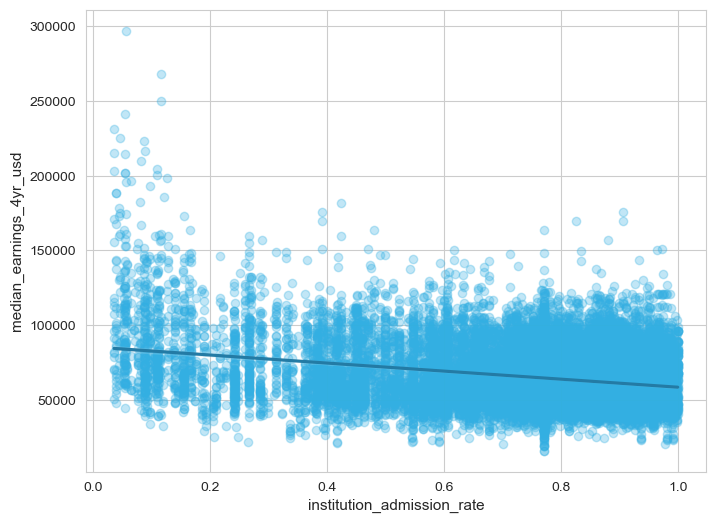

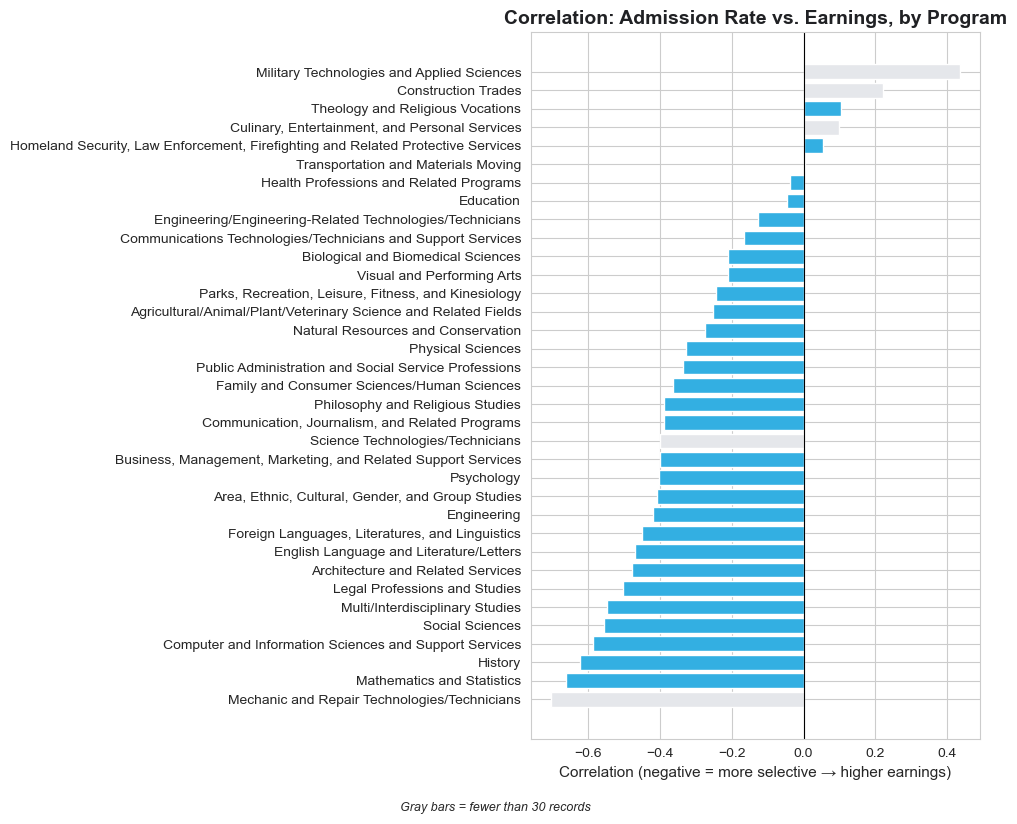

In [31]:
# Making Charts and answering initial questions
sns.set_style("whitegrid")

# -------------------------------------------------------------------------------------------------------
# Question 1: Does selectivity affect earnings? Does this change depending on a general or program level?
# Recall: A lower rate means more selective. So a negative correlation implies that a more selective school
# has higher earning graduates

# General level
overall_corr = earnings_df["institution_admission_rate"].corr(earnings_df["median_earnings_4yr_usd"])
print(f"Overall correlation (admission rate vs earnings): {overall_corr:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=earnings_df,
    x="institution_admission_rate",
    y="median_earnings_4yr_usd",
    scatter_kws={"color": PRIMARY_BLUE, "alpha": 0.3},
    line_kws={"color": DARK_BLUE}
)

# Program level
program_corr = (
    earnings_df.groupby("cip_family_title")
    .apply(lambda g: g["institution_admission_rate"].corr(g["median_earnings_4yr_usd"]), include_groups=False)
    .dropna()
    .sort_values()
    .reset_index(name="selectivity_earnings_corr")
)

# Correlation has little significance when there are programs with few associated records.
# Thus, we flag those with less than 30
program_counts = earnings_df.groupby("cip_family_title").size().reset_index(name="n_records")
program_corr = program_corr.merge(program_counts, on="cip_family_title")
MIN_RECORDS = 30
program_corr["low_sample_flag"] = program_corr["n_records"] < MIN_RECORDS
program_corr.sort_values("selectivity_earnings_corr")

plt.figure(figsize=(10, 8))
colors = [LIGHT_GRAY if flag else PRIMARY_BLUE for flag in program_corr["low_sample_flag"]]

plt.barh(program_corr["cip_family_title"], program_corr["selectivity_earnings_corr"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation: Admission Rate vs. Earnings, by Program")
plt.xlabel("Correlation (negative = more selective → higher earnings)")
plt.figtext(0.5, -0.02, f"Gray bars = fewer than {MIN_RECORDS} records",
            ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()

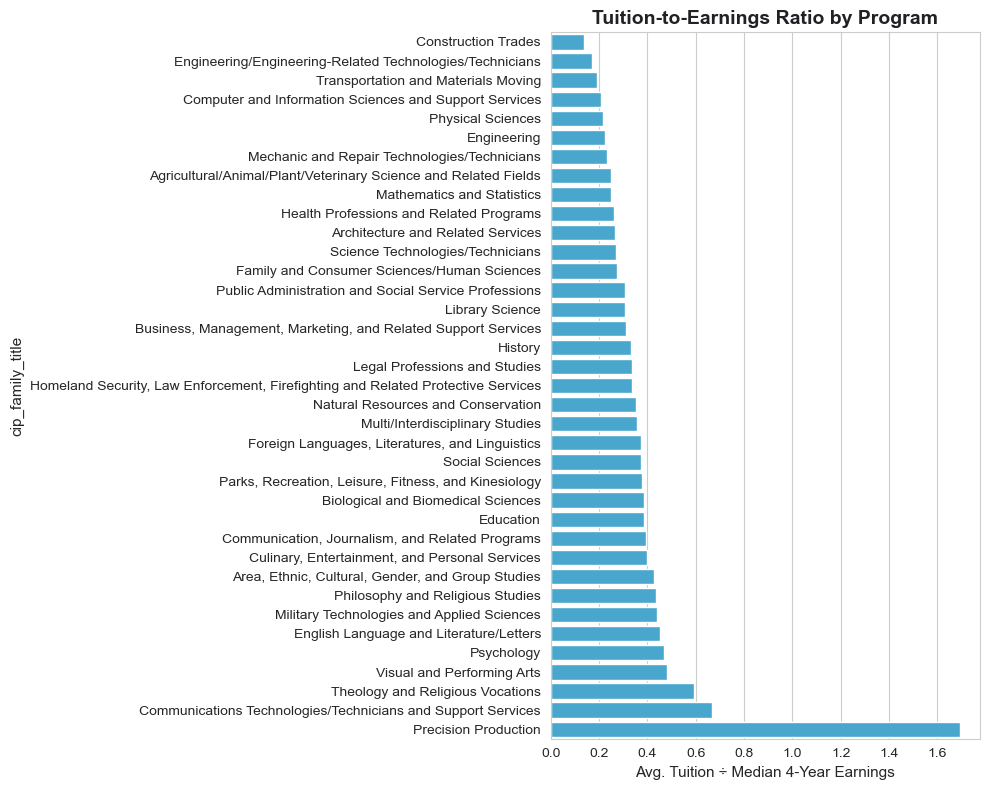

In [22]:
# -------------------------------------------------------------------------------------------------------
# 2. Tuition-to-earnings ratio by program (which programs are "worth it financially")
# Lower ratio = less tuition relative to what you earn.

earnings_df["tuition_to_earnings_ratio"] = (
    earnings_df["institution_tuition_in_state_usd"] / earnings_df["median_earnings_4yr_usd"]
)

ratio_by_program = (
    earnings_df.groupby("cip_family_title")["tuition_to_earnings_ratio"]
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=ratio_by_program, y="cip_family_title", x="tuition_to_earnings_ratio", color=PRIMARY_BLUE)
plt.title("Tuition-to-Earnings Ratio by Program")
plt.xlabel("Avg. Tuition ÷ Median 4-Year Earnings")
plt.tight_layout()
plt.show()

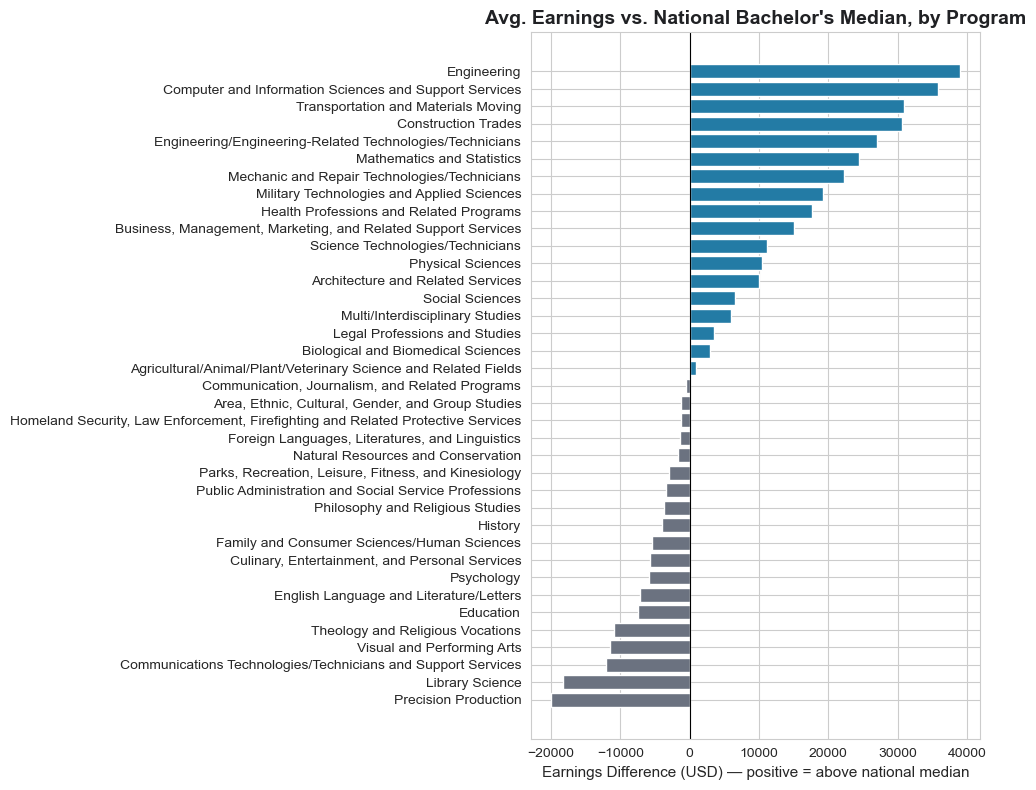

In [23]:
# -------------------------------------------------------------------------------------------------------
# 3. Earnings vs. national bachelor's median, by program
# Positive: The median 4-year earnings for a graduate from the 
# program are higher than the median four-year earnings of the median 
# american bachelors graduate

diff_by_program = (
    earnings_df.groupby("cip_family_title")["earnings_difference"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

colors = [DARK_BLUE if v > 0 else GRAY for v in diff_by_program["earnings_difference"]]

plt.figure(figsize=(10, 8))
plt.barh(diff_by_program["cip_family_title"], diff_by_program["earnings_difference"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Avg. Earnings vs. National Bachelor's Median, by Program")
plt.xlabel("Earnings Difference (USD) — positive = above national median")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

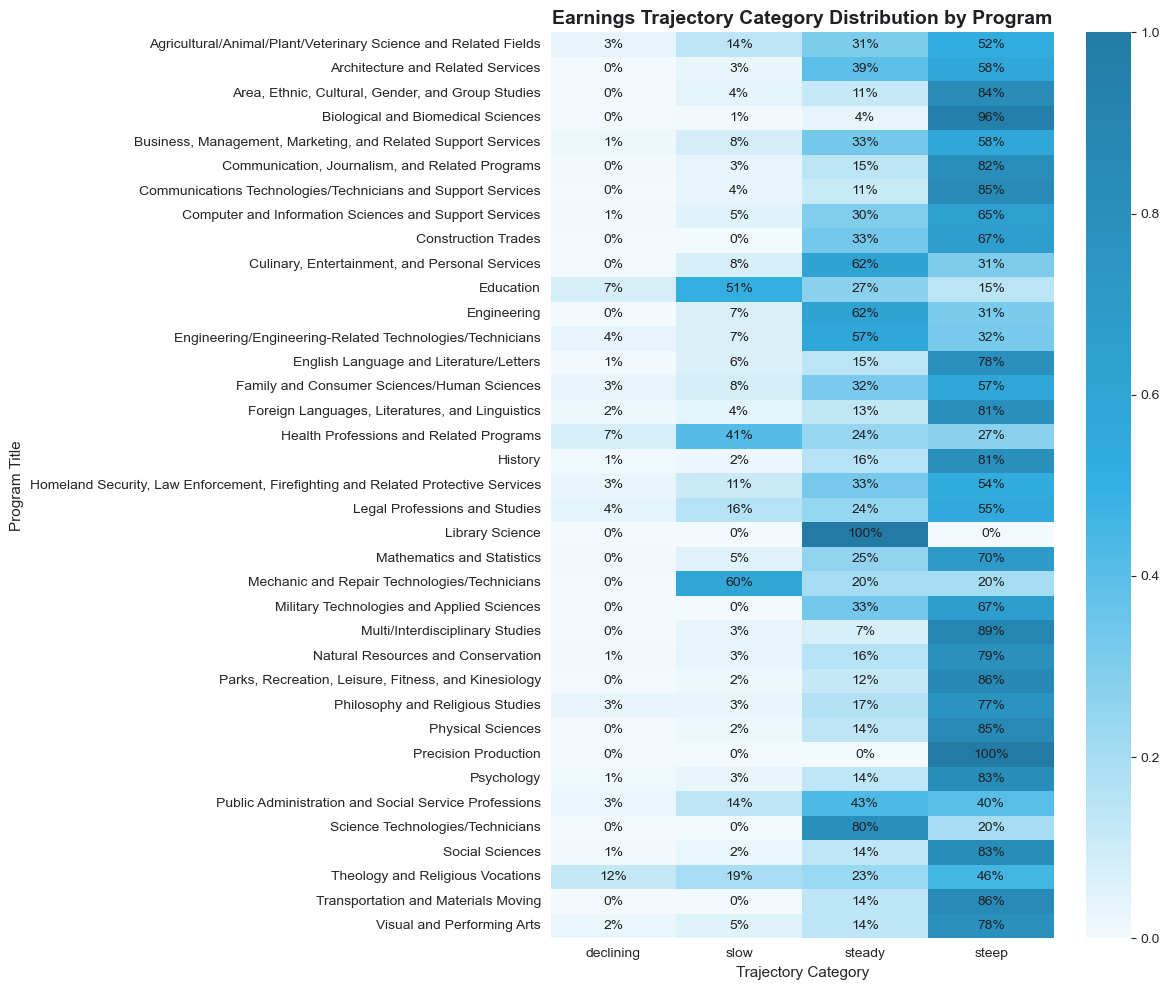

,cip_family_title,most_common_trajectory
0,Agricultural/Animal/Plant/Veterinary Science a...,steep
1,Architecture and Related Services,steep
2,"Area, Ethnic, Cultural, Gender, and Group Studies",steep
3,Biological and Biomedical Sciences,steep
4,"Business, Management, Marketing, and Related S...",steep
5,"Communication, Journalism, and Related Programs",steep
6,Communications Technologies/Technicians and Su...,steep
7,Computer and Information Sciences and Support ...,steep
8,Construction Trades,steep
9,"Culinary, Entertainment, and Personal Services",steady


In [24]:
# ------------------------------------------------------------------
# 4. Earnings trajectory by program
# Categorical column -> heatmap shows the full distribution per program,
# not just the single most common category.

trajectory_dist = pd.crosstab(
    earnings_df["cip_family_title"],
    earnings_df["earnings_trajectory_category"],
    normalize="index"
)

plt.figure(figsize=(12, 10))
sns.heatmap(trajectory_dist, cmap=blue_cmap, annot=True, fmt=".0%", annot_kws={"color": NEAR_BLACK})
plt.title("Earnings Trajectory Category Distribution by Program")
plt.xlabel("Trajectory Category")
plt.ylabel("Program Title")
plt.tight_layout()
plt.show()

# Optional: simple one-line summary — single most common trajectory per program
most_common_trajectory = (
    earnings_df.groupby("cip_family_title")["earnings_trajectory_category"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name="most_common_trajectory")
)
most_common_trajectory

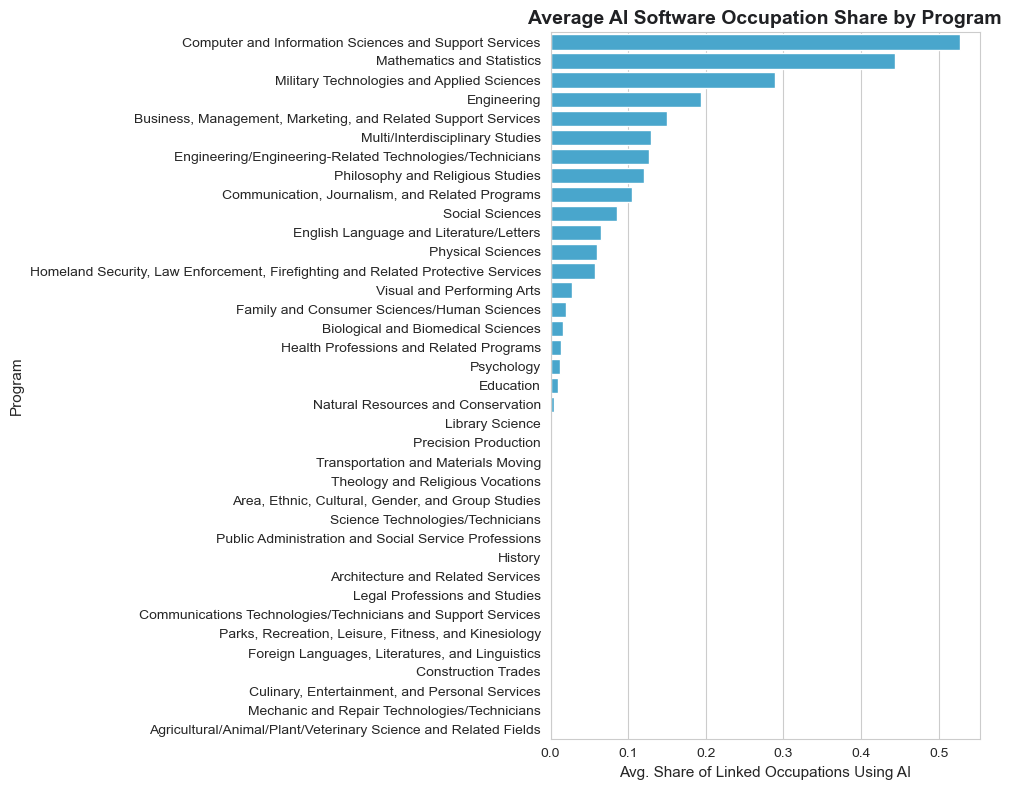

In [25]:
sns.set_style("whitegrid")

# ------------------------------------------------------------------
# 1. AI software occupation share by program, the proportion of 
#linked occupations that use AI software.

ai_share = (
    df.groupby("cip_family_title")["ai_software_occupation_share"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=ai_share, y="cip_family_title", x="ai_software_occupation_share", color=PRIMARY_BLUE)
plt.title("Average AI Software Occupation Share by Program")
plt.xlabel("Avg. Share of Linked Occupations Using AI")
plt.ylabel("Program")
plt.tight_layout()
plt.show()

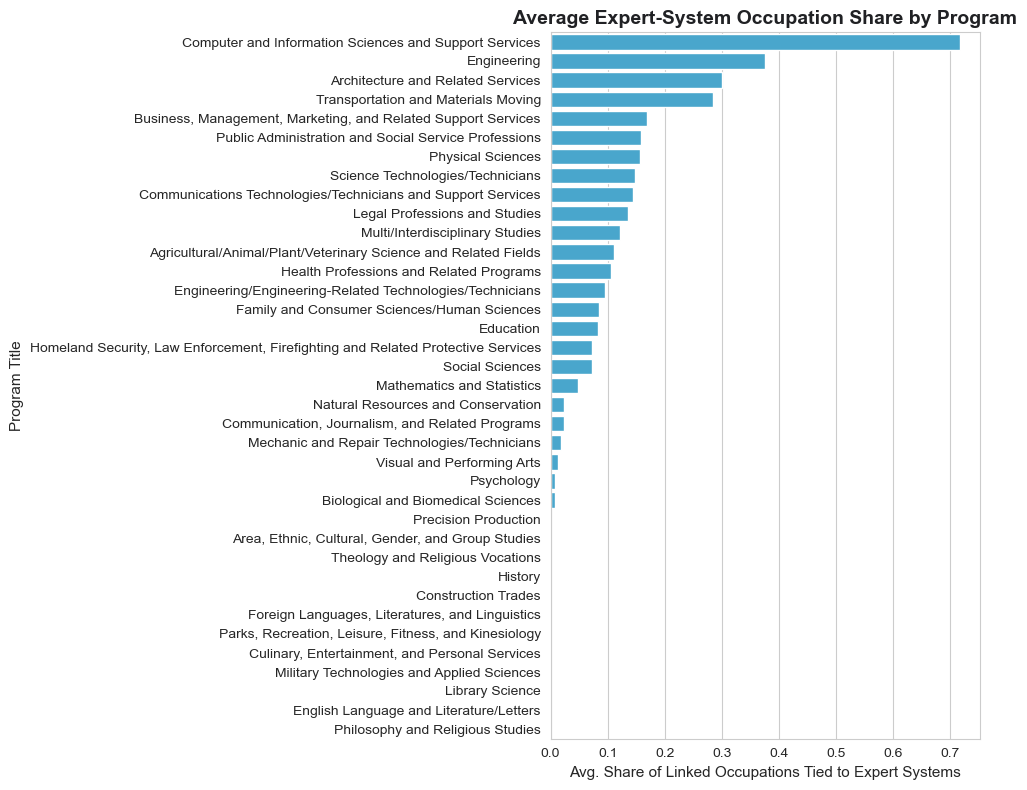

In [26]:
# -------------------------------------------------------------------------------------------------------
# The proportion of linked occupations associated with expert-system technology. 
# Expert systems are AI systems designed to perform tasks that traditionally require 
# human expertise, often using rules/knowledge bases.

expert_share = (
    df.groupby("cip_family_title")["expert_system_occupation_share"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=expert_share, y="cip_family_title", x="expert_system_occupation_share", color=PRIMARY_BLUE)
plt.title("Average Expert-System Occupation Share by Program")
plt.xlabel("Avg. Share of Linked Occupations Tied to Expert Systems")
plt.ylabel("Program Title")
plt.tight_layout()
plt.show()

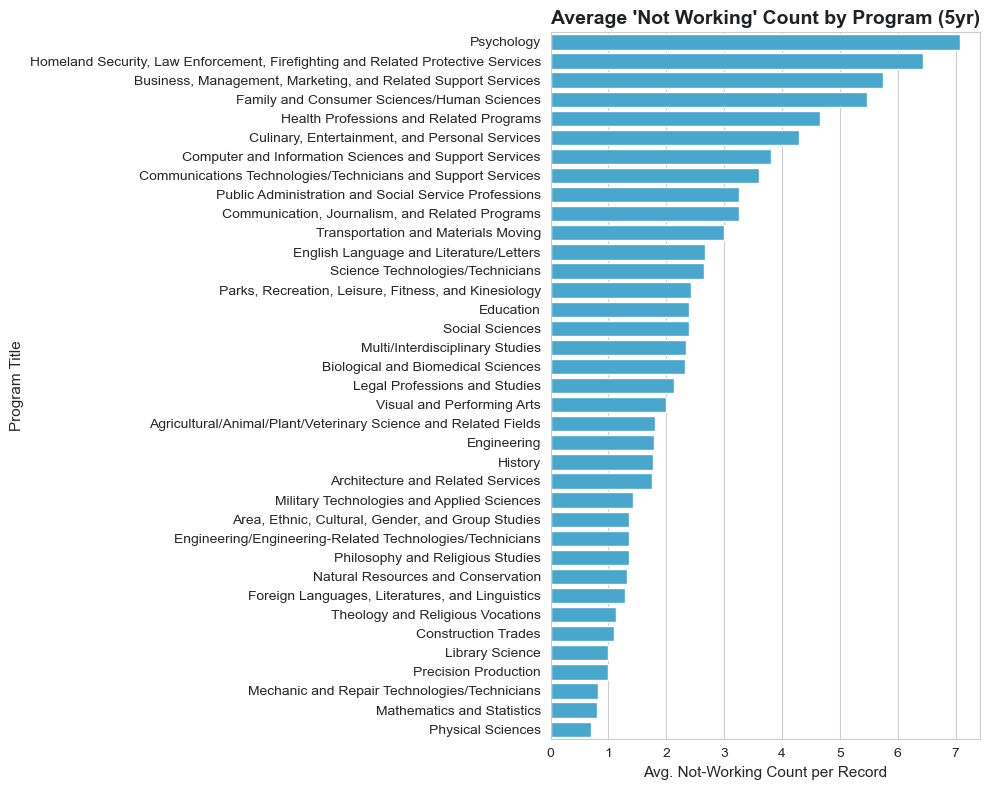

In [27]:
# -------------------------------------------------------------------------------------------------------
# Highest "not working" by program
# NOTE: this is a raw count, not a true rate, since there's no total-students column to divide by. 
# Consider this to be a relative comparison, not an actual percentage.
not_working = (
    df.groupby("cip_family_title")["not_working_count_5yr"]
      .mean()   # avg per record within that program
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=not_working, y="cip_family_title", x="not_working_count_5yr", color=PRIMARY_BLUE)
plt.title("Average 'Not Working' Count by Program (5yr)")
plt.xlabel("Avg. Not-Working Count per Record")
plt.ylabel("Program Title")
plt.tight_layout()
plt.show()

In [28]:
# -------------------------------------------------------------------------------------------------------
# 4. Most common linked occupation by program
def top_occupation(x):
    counts = x.value_counts()
    return pd.Series({"top_occupation": counts.idxmax(), "count": counts.max()})

top_occ_by_program = (
    df.groupby("cip_family_title")["largest_linked_occupation"]
      .apply(top_occupation)
      .unstack()
      .sort_values("count", ascending=False)
)

top_occ_by_program

,top_occupation,count
cip_family_title,,
Social Sciences,"Managers, all other",4666
"Business, Management, Marketing, and Related Support Services",General and operations managers,4002
"Foreign Languages, Literatures, and Linguistics","Secondary school teachers, except special and ...",2415
Computer and Information Sciences and Support Services,Software developers,2409
Education,"Elementary school teachers, except special edu...",2355
Visual and Performing Arts,"Secondary school teachers, except special and ...",2165
Physical Sciences,"Secondary school teachers, except special and ...",2057
Psychology,"Managers, all other",1906
Engineering,Architectural and engineering managers,1861


In [29]:
# ============================================================
# SANKEY DIAGRAM
# Program of Study -> Most Common Linked Occupation
# ============================================================

import pandas as pd
import plotly.graph_objects as go
import textwrap


# ---------------- Palette ----------------

PRIMARY_BLUE    = "#33AFE2"
DARK_BLUE       = "#237BA5"
BG_LIGHT_BLUE   = "#F2FAFD"
DARK_CHARCOAL   = "#404040"
NEAR_BLACK      = "#202124"
GRAY            = "#6B7280"
LIGHT_GRAY      = "#E5E7EB"
VERY_LIGHT_GRAY = "#F5F7F9"
WHITE           = "#FFFFFF"


# ============================================================
# 1. Choose the columns
# ============================================================

program_col = "cip_family_title"
occupation_col = "largest_linked_occupation"


# ============================================================
# 2. Clean the data
# ============================================================

sankey_df = (
    df[[program_col, occupation_col]]
    .dropna()
    .copy()
)

sankey_df[program_col] = sankey_df[program_col].str.strip()
sankey_df[occupation_col] = sankey_df[occupation_col].str.strip()


# ============================================================
# 3. Count program -> occupation links
# ============================================================

flows = (
    sankey_df
    .groupby([program_col, occupation_col])
    .size()
    .reset_index(name="count")
)


# ============================================================
# 4. OPTIONAL: keep only the largest programs
#
# Sankey diagrams become difficult to read if there are too
# many starting nodes.
# ============================================================

TOP_N_PROGRAMS = 15

top_programs = (
    sankey_df[program_col]
    .value_counts()
    .head(TOP_N_PROGRAMS)
    .index
)

flows = flows[
    flows[program_col].isin(top_programs)
].copy()


# ============================================================
# 5. Sort programs so the diagram looks more intentional
# ============================================================

program_order = (
    flows.groupby(program_col)["count"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

occupation_order = (
    flows.groupby(occupation_col)["count"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)


# ============================================================
# 6. Create unique node labels
# ============================================================

programs = program_order
occupations = occupation_order

all_nodes = programs + occupations

node_index = {
    node: i
    for i, node in enumerate(all_nodes)
}


# ============================================================
# 7. Convert flows into Sankey source / target indexes
# ============================================================

sources = flows[program_col].map(node_index).tolist()
targets = flows[occupation_col].map(node_index).tolist()
values = flows["count"].tolist()


# ============================================================
# 8. Shorten long labels for presentation
# ============================================================

def wrap_label(label, width=25):
    """
    Adds line breaks to long labels so they fit better
    inside a PowerPoint slide.
    """
    return "<br>".join(textwrap.wrap(str(label), width=width))


display_labels = [
    wrap_label(label)
    for label in all_nodes
]


# ============================================================
# 9. Colours
#
# Programs = primary blue
# Occupations = dark charcoal
# Flows = transparent blue
# ============================================================

program_colors = [PRIMARY_BLUE] * len(programs)
occupation_colors = [DARK_CHARCOAL] * len(occupations)

node_colors = program_colors + occupation_colors

link_colors = [
    "rgba(51, 175, 226, 0.28)"
    for _ in values
]


# ============================================================
# 10. Build Sankey diagram
# ============================================================

fig = go.Figure(
    data=[
        go.Sankey(

            arrangement="snap",

            node=dict(
                pad=18,
                thickness=17,

                line=dict(
                    color=WHITE,
                    width=1
                ),

                label=display_labels,
                color=node_colors,

                hovertemplate=(
                    "%{label}"
                    "<extra></extra>"
                )
            ),

            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors,

                hovertemplate=(
                    "%{source.label}"
                    " → "
                    "%{target.label}"
                    "<br>Observations: %{value:,}"
                    "<extra></extra>"
                )
            )
        )
    ]
)


# ============================================================
# 11. Apply your presentation style
# ============================================================

fig.update_layout(

    title=dict(
        text=(
            "<b>Where Do Graduates Go After College?</b>"
            "<br>"
            "<span style='font-size:14px; color:#6B7280;'>"
            "Most common linked occupation by program"
            "</span>"
        ),
        x=0.02,
        xanchor="left"
    ),

    font=dict(
        family="Sans-serif",
        size=12,
        color=NEAR_BLACK
    ),

    paper_bgcolor=WHITE,
    plot_bgcolor=WHITE,

    width=1600,
    height=900,

    margin=dict(
        l=40,
        r=40,
        t=110,
        b=40
    )
)


fig.show()

In [ ]:
fig.write_image(
    "program_to_occupation_sankey.png",
    width=1600,
    height=900,
    scale=2
)

C:\Users\cricb
